# GARCH(1,1) Market Risk Model — ETERNAL.NS (Zomato)
### Dynamic Volatility, Value at Risk & Expected Shortfall
**Stock:** ETERNAL.NS | **Period:** July 2021 – May 2026 | **Model:** GARCH(1,1)

This notebook builds a dynamic market risk model from scratch using GARCH(1,1) conditional volatility estimation, 
99% Value at Risk forecasting, backtesting, and Expected Shortfall. 
Replicating the core framework used by risk desks under Basel III.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
from arch import arch_model

## 1. Data & Log Returns
Daily adjusted closing prices for ETERNAL.NS are sourced via yfinance from Zomato's NSE listing date. 
Log returns are computed as ln(Pt/Pt-1). The return series exhibits clear **volatility clustering** — 
large moves tend to follow large moves, and calm periods cluster together. This violates the constant 
variance assumption of simple models and motivates the use of GARCH.
    

In [2]:
data = yf.download(tickers = "ETERNAL.NS", start = "2021-7-23", 
            auto_adjust = True)
price = data["Close"].dropna()

[*********************100%***********************]  1 of 1 completed


In [3]:
price.tail()

Ticker,ETERNAL.NS
Date,
2026-05-18,241.399994
2026-05-19,247.210007
2026-05-20,243.339996
2026-05-21,242.050003
2026-05-22,241.949997


In [4]:
log_returns = np.log(price/ price.shift(1)).dropna().squeeze()
log_returns.describe()

count    1171.000000
mean        0.000557
std         0.030355
min        -0.218425
25%        -0.015153
50%         0.000000
75%         0.016712
max         0.182142
Name: ETERNAL.NS, dtype: float64

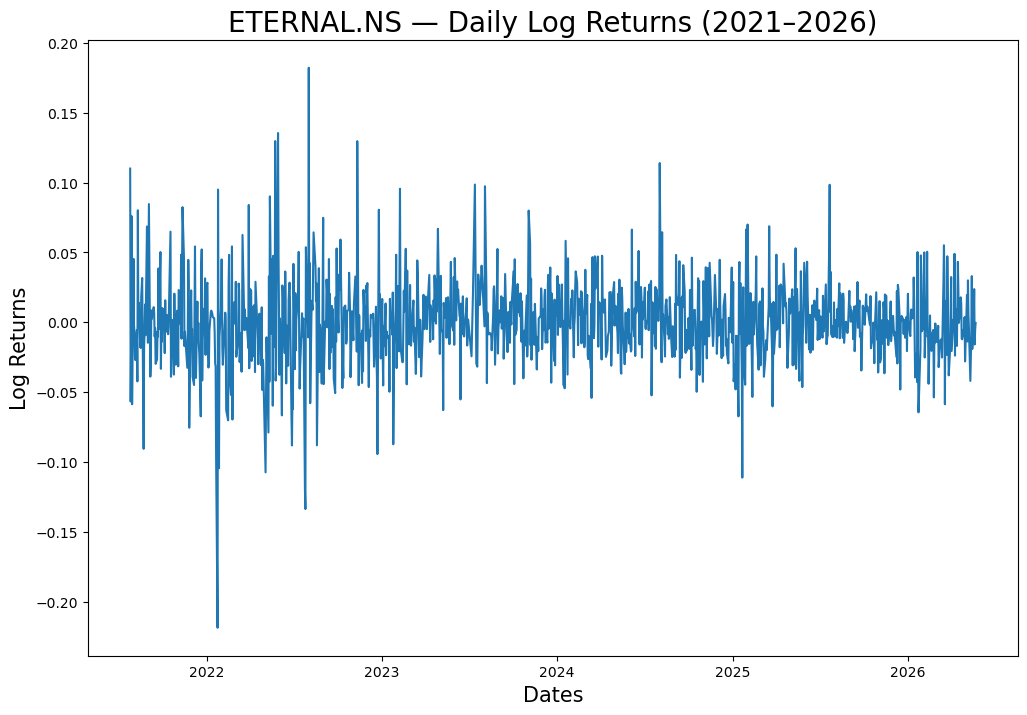

In [5]:
plt.figure(figsize = (12,8))
plt.plot(log_returns)
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Log Returns", fontsize = 15)
plt.title("ETERNAL.NS — Daily Log Returns (2021–2026)", fontsize = 20)
plt.show()

## 2. GARCH(1,1) Estimation
The GARCH(1,1) model estimates conditional variance as:

    σ²t = ω + α·ε²t-1 + β·σ²t-1

- **ω = 0.0000923** — variance intercept; implies long run daily volatility of ~3.02%
- **α = 0.0999** — shock sensitivity; large moves yesterday increase today's variance by ~10%
- **β = 0.7989** — persistence; 80% of yesterday's variance carries into today
- **α + β = 0.8988** — below 1, confirming the process is stationary and volatility mean-reverts

In [6]:
model = arch_model(log_returns, p = 1, q = 1, vol = "Garch")
result = model.fit(disp = "off")

C:\Users\sayee\anaconda3\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0009207. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [7]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:             ETERNAL.NS   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                2496.76
Distribution:                  Normal   AIC:                          -4985.52
Method:            Maximum Likelihood   BIC:                          -4965.26
                                        No. Observations:                 1171
Date:                Sat, May 23 2026   Df Residuals:                     1170
Time:                        03:22:18   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.3032e-03  7.577e-04      1.720  8.545e-02 [-1.819e-04,2.788e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      9.2072e-05  5.023e-05      1.833  6.682e-02 [-6.383e-06,1.905e-04]
alpha[1]       0.1000  4.830e-02      2.071  3.840e-02    [5.340e-03,  0.195]
beta[1]        0.8000  8.670e-02      9.227  2.773e-20      [  0.630,  0.970]
=============================================================================

Covariance estimator: robust
"""

In [8]:
cond_vol = result.conditional_volatility.squeeze()
cond_vol

Date
2021-07-26    0.045577
2021-07-27    0.054177
2021-07-28    0.052692
2021-07-29    0.048304
2021-07-30    0.050156
                ...   
2026-05-18    0.027269
2026-05-19    0.026210
2026-05-20    0.026309
2026-05-21    0.025980
2026-05-22    0.025228
Name: cond_vol, Length: 1171, dtype: float64

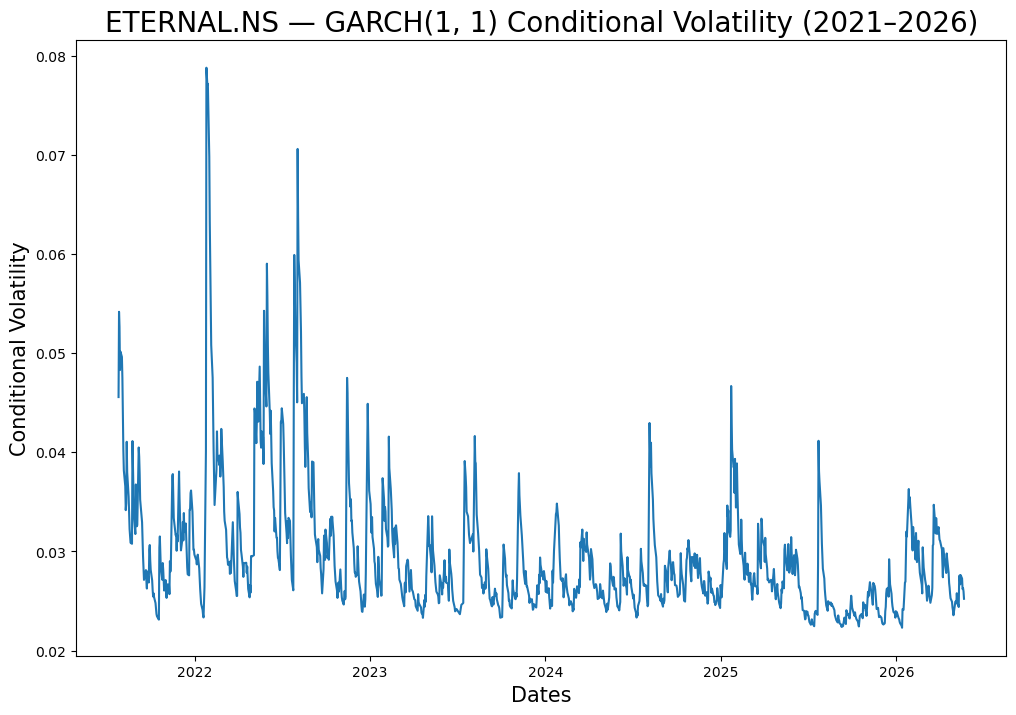

In [9]:
plt.figure(figsize = (12,8))
plt.plot(cond_vol)
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Conditional Volatility", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1, 1) Conditional Volatility (2021–2026)", fontsize = 20)
plt.show()

## 3. Value at Risk (99%)
1-day 99% VaR is computed as:

    VaR = μ - z·σt  ,  where z = 2.326 (99th percentile)

Unlike static VaR models, GARCH-based VaR updates daily with the conditional volatility estimate, widening during stress periods and tightening during calm regimes. **Backtesting result: 14 breaches out of 1,165 days (1.20%)**.

In [10]:
z = stats.norm.ppf(0.99)
z

np.float64(2.3263478740408408)

In [11]:
mean = log_returns.mean()

In [12]:
VaR_99 = mean - z * cond_vol
VaR_99

Date
2021-07-26   -0.105470
2021-07-27   -0.125478
2021-07-28   -0.122022
2021-07-29   -0.111815
2021-07-30   -0.116123
                ...   
2026-05-18   -0.062879
2026-05-19   -0.060416
2026-05-20   -0.060647
2026-05-21   -0.059882
2026-05-22   -0.058131
Name: cond_vol, Length: 1171, dtype: float64

In [13]:
breaches = log_returns < VaR_99
breaches

Date
2021-07-26    False
2021-07-27    False
2021-07-28    False
2021-07-29    False
2021-07-30    False
              ...  
2026-05-18    False
2026-05-19    False
2026-05-20    False
2026-05-21    False
2026-05-22    False
Length: 1171, dtype: bool

In [14]:
breach_days = log_returns[breaches]
breach_days

Date
2021-08-23   -0.090476
2021-11-26   -0.075385
2021-12-20   -0.067227
2022-01-21   -0.096789
2022-01-24   -0.218425
2022-05-04   -0.107298
2022-06-27   -0.068233
2022-06-28   -0.088047
2022-07-25   -0.119649
2022-07-26   -0.133531
2022-12-23   -0.094208
2023-01-25   -0.087186
2025-01-13   -0.067245
2025-01-21   -0.111054
Name: ETERNAL.NS, dtype: float64

In [15]:
len(breach_days)

14

In [16]:
len(breach_days) / len(log_returns) * 100

1.1955593509820666

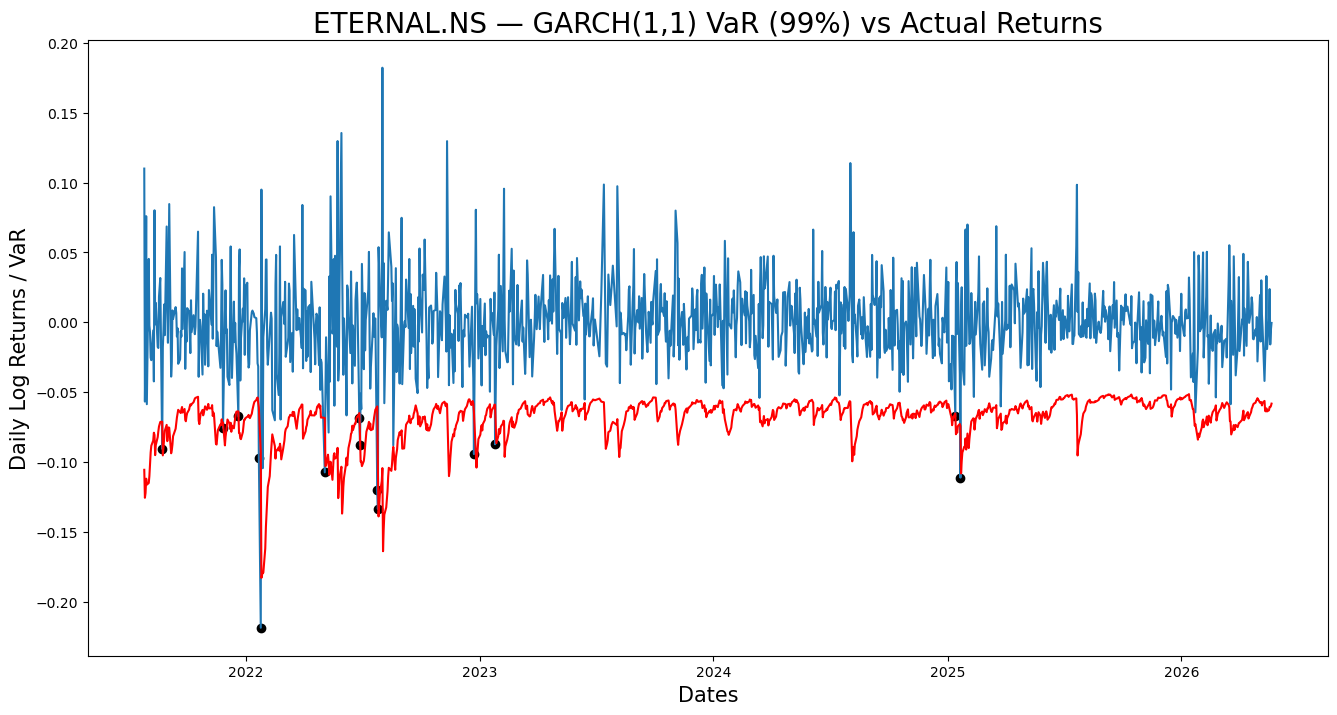

In [17]:
plt.figure(figsize = (16,8))
plt.plot(log_returns)
plt.plot(VaR_99, color = "red")
plt.scatter(breach_days.index, breach_days.values, color = "Black")
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Daily Log Returns / VaR", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1,1) VaR (99%) vs Actual Returns", fontsize = 20)
plt.show()

## 4. Expected Shortfall (99%)
**ES = -10.18%**

Expected Shortfall answers what VaR cannot, given that we have already breached VaR, what is the average loss on those worst days? ES is the mean of all 14 breach day returns. The gap between VaR (~6% in calm periods) and ES (-10.18%) highlights the fat-tailed nature of Zomato's return distribution.

In [18]:
ES_99 = breach_days.mean()
ES_99

np.float64(-0.10176811968144957)

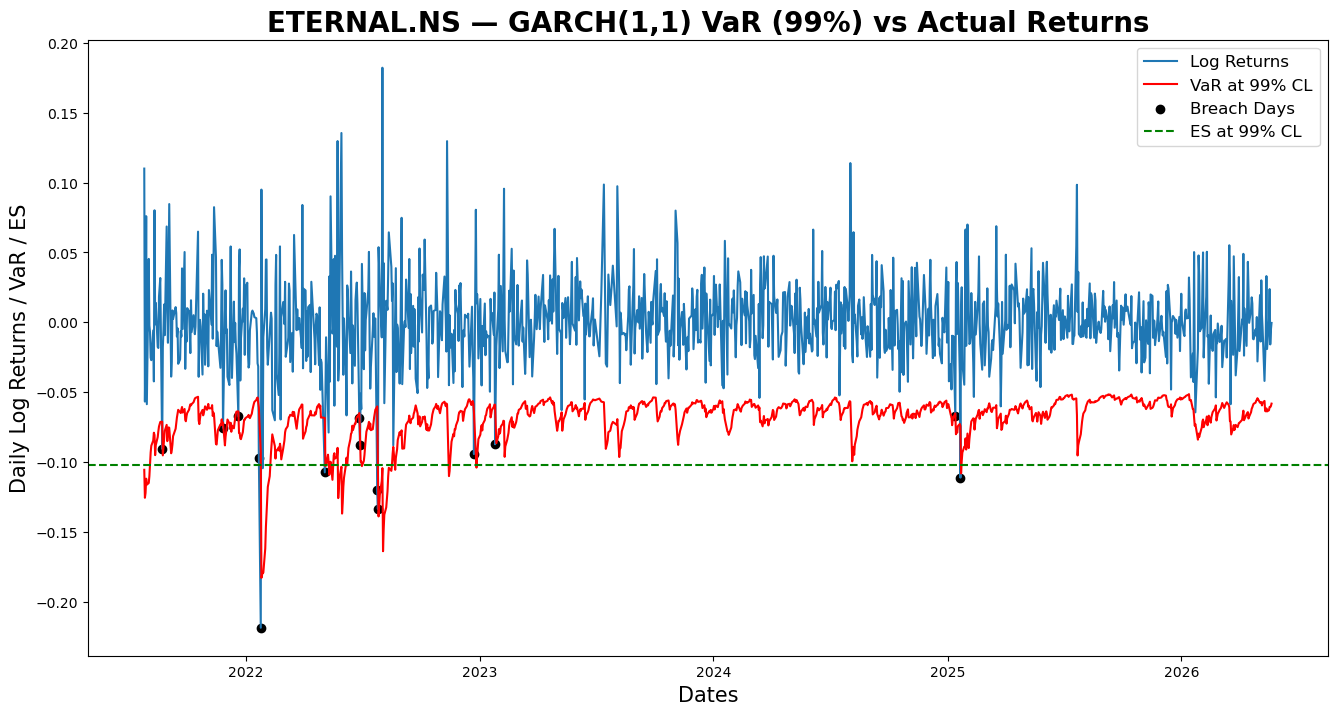

In [19]:
plt.figure(figsize = (16,8))
plt.plot(log_returns, label = "Log Returns")
plt.plot(VaR_99, color = "red", label = "VaR at 99% CL")
plt.scatter(breach_days.index, breach_days.values, color = "Black", label = "Breach Days")
plt.axhline(ES_99, color = "Green", linestyle = "--", label = "ES at 99% CL")
plt.xlabel("Dates", fontsize = 15)
plt.ylabel("Daily Log Returns / VaR / ES", fontsize = 15)
plt.title("ETERNAL.NS — GARCH(1,1) VaR (99%) vs Actual Returns", fontsize = 20, fontweight='bold')
plt.legend(loc = "best", fontsize = 12)
plt.show()

#### **Prepared by:** Yusuf Sayeed | FRM Part 1 Cleared | FMVA